# Environment Sanity Check

Run this notebook before starting the PwC Data Science Graduate Program assessment.
It checks that the core Python data science stack and Streamlit are installed and import correctly.

## 1. Python and runtime details

In [13]:
import platform
import sys
from pathlib import Path

print(f"Python executable: {sys.executable}")
print(f"Python version:    {sys.version.split()[0]}")
print(f"Platform:          {platform.platform()}")
print(f"Working folder:    {Path.cwd()}")

Python executable: c:\Python313\python.exe
Python version:    3.13.6
Platform:          Windows-11-10.0.26200-SP0
Working folder:    c:\4th year\pwc assessment\Data-Science-Graduate-Program-Assessment


## 2. Required package imports

In [8]:
from importlib import import_module

required_packages = {
    "numpy": "Numerical computing",
    "pandas": "Data loading and analysis",
    "matplotlib": "Static plots",
    "seaborn": "Statistical visualisation",
    "sklearn": "Machine learning",
    "scipy": "Scientific computing",
    "plotly": "Interactive charts",
    "streamlit": "Interactive dashboard app",
    "jupyter": "Notebook environment",
    "ipykernel": "Jupyter kernel",
}

results = []
for package_name, purpose in required_packages.items():
    try:
        module = import_module(package_name)
        version = getattr(module, "__version__", "installed")
        status = "OK"
    except Exception as exc:
        version = "not installed"
        status = f"FAILED: {type(exc).__name__}: {exc}"
    results.append({"package": package_name, "purpose": purpose, "version": version, "status": status})

import pandas as pd

results_df = pd.DataFrame(results)
results_df

,package,purpose,version,status
0,numpy,Numerical computing,2.3.3,OK
1,pandas,Data loading and analysis,2.3.2,OK
2,matplotlib,Static plots,3.10.6,OK
3,seaborn,Statistical visualisation,0.13.2,OK
4,sklearn,Machine learning,1.7.2,OK
5,scipy,Scientific computing,1.16.2,OK
6,plotly,Interactive charts,6.3.0,OK
7,streamlit,Interactive dashboard app,1.57.0,OK
8,jupyter,Notebook environment,installed,OK
9,ipykernel,Jupyter kernel,6.30.1,OK


In [9]:
failed = results_df[results_df["status"] != "OK"]
if failed.empty:
    print("All required assessment packages imported successfully.")
else:
    print("Some packages failed to import:")
    display(failed)

All required assessment packages imported successfully.


## 3. Tiny data science smoke test

In [10]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

rng = np.random.default_rng(42)
x = np.arange(30).reshape(-1, 1)
y = 3 * x.ravel() + 7 + rng.normal(0, 2, size=30)

model = LinearRegression()
model.fit(x, y)
predictions = model.predict(x)

smoke_test_df = pd.DataFrame({"x": x.ravel(), "actual": y, "prediction": predictions})
print(f"Model coefficient: {model.coef_[0]:.3f}")
print(f"Model intercept:   {model.intercept_:.3f}")
print(f"R2 score:          {r2_score(y, predictions):.3f}")
smoke_test_df.head()

Model coefficient: 3.033
Model intercept:   6.552
R2 score:          0.997


,x,actual,prediction
0,0,7.609434,6.551970
1,1,7.920032,9.585187
2,2,14.500902,12.618405
3,3,17.881129,15.651623
4,4,15.097930,18.684841


## 4. Plotting smoke test

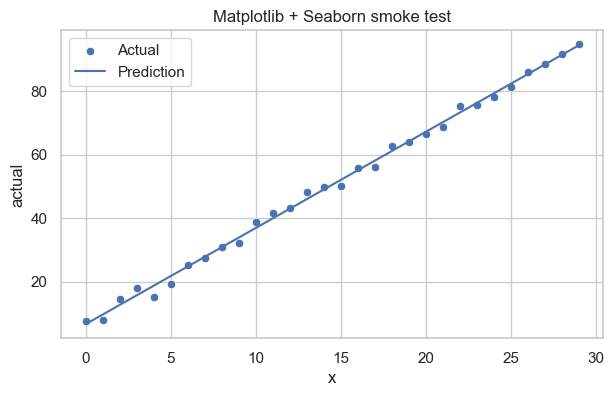

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=smoke_test_df, x="x", y="actual", label="Actual", ax=ax)
sns.lineplot(data=smoke_test_df, x="x", y="prediction", label="Prediction", ax=ax)
ax.set_title("Matplotlib + Seaborn smoke test")
plt.show()

## 5. Streamlit CLI check

In [12]:
import sys
import subprocess

completed = subprocess.run(
    [sys.executable, "-m", "streamlit", "--version"],
    capture_output=True,
    text=True,
    check=False,
)

if completed.returncode == 0:
    print(completed.stdout.strip())
else:
    print("Streamlit could not be launched with python -m streamlit.")
    print(completed.stderr.strip())

Streamlit, version 1.57.0


If any package is missing, install the common assessment stack with:

```bash
python -m pip install numpy pandas matplotlib seaborn scikit-learn scipy plotly streamlit jupyter ipykernel
```